# Feature Engineering: Signal Processing and Frequency Domain Transformation

## Abstract
Raw light curves contain significant stellar noise and instrumental artifacts that can obscure planetary transits. This notebook focuses on transforming time-series data from the **Time Domain** to the **Frequency Domain** using **Fast Fourier Transform (FFT)**. 

## Objectives
1. **Signal Detrending:** Remove low-frequency stellar variability and long-term drifts to isolate the transit signal.
2. **Spectral Analysis:** Apply FFT to convert flux intensity over time into a power spectrum. This helps identify periodic signals (planetary orbits) that appear as distinct peaks in the frequency domain.
3. **Feature Extraction:** Generate new frequency-based features to augment the existing `features_dataset`, improving the model's ability to distinguish between noise and real transits.

# Step 1: Imports & Loading Data


In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq

import sys 
import os 

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df_flux = pd.read_csv('../data/processed/clean_flux.csv')
df_time = pd.read_csv('../data/processed/clean_time.csv')
df_features = pd.read_csv('../data/processed/clean_features.csv')

In [3]:
def detrend_light_curve(flux_array, window_lenght=101, polyorder=3):
    """
    Applies the Savitzky-Golay filter to extract the trend and remove it.
    
    Parameters:
    - flux_array: a numpy array with brightness values.
    - window_length: the size of the sliding window (must be odd).
    - polyorder: the order of the polynomial for approximation (usually 2 or 3).
    
    Returns:
    - detrended_flux: aligned signal.
    - trend: A dedicated low-frequency trend.
    """

    # 1. Extracting the trend (smoothed line)
    trend = savgol_filter(flux_array, window_length=window_lenght, polyorder=polyorder)

    # 2. Subtract the trend from the raw signal. 
    # Add 1.0 to normalize the graph around the unit (baseline).
    detrended_flux = (flux_array - trend) + 1.0

    return detrended_flux, trend

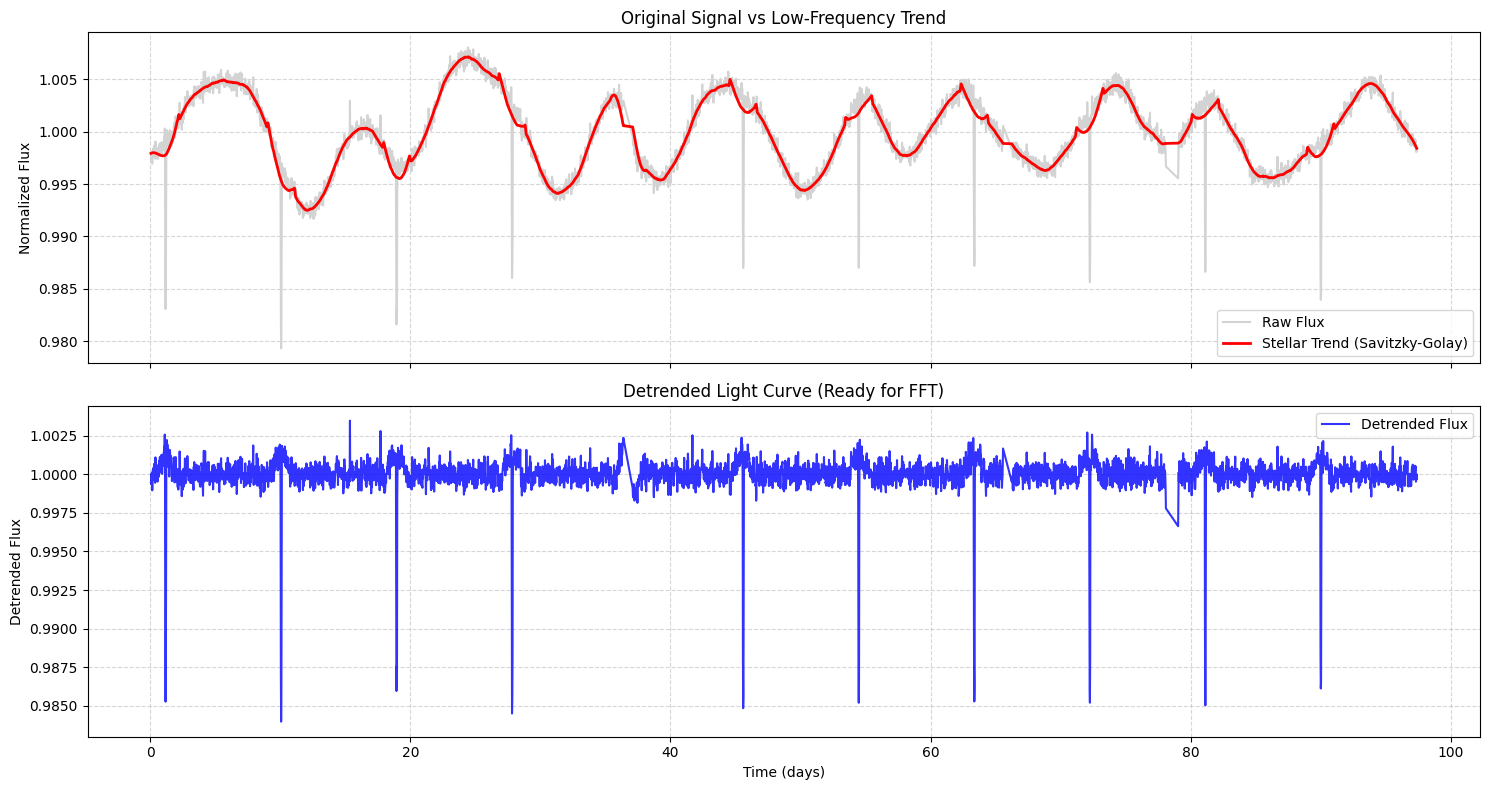

In [ ]:
# Downloading data from Phase 1 
# It is assumed that df_time and df_flux are in memory


idx_class_1 = df_time[df_time['class'] == 1].index[0]

time_vals = df_time.drop(columns=['id', 'class']).iloc[idx_class_1].values
raw_flux = df_flux.drop(columns=['id', 'class']).iloc[idx_class_1].values

# Applying detrending
detrended_flux, trend = detrend_light_curve(raw_flux)
    
# Visualization (Before vs After)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(time_vals, raw_flux, label='Raw Flux', color='lightgray')
ax1.plot(time_vals, trend, label='Stellar Trend (Savitzky-Golay)', color='red', linewidth=2)
ax1.set_title("Original Signal vs Low-Frequency Trend")
ax1.set_ylabel("Normalized Flux")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(time_vals, detrended_flux, label='Detrended Flux', color='blue', alpha=0.8)
ax2.set_title("Detrended Light Curve (Ready for FFT)")
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Detrended Flux")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Fast Fourier Transform (FFT) for frequency domain transformation
Accepts a cleared time series (detrended flux) and returns the Power Spectrum.
`from scipy.fft import fft, fftfreq`


In [5]:
def compute_fft(flux_array, time_interval):
    """
        Calculates the Fast Fourier Transform (FFT) for the cleared time series.

        Parameters:
        - flux_array: a numpy array with values of cleared brightness (Detrended flux).
        - time_interval: the average time step between observations (dt).

        Returns:
        - positive_freqs: array of frequencies (Frequency domain).
        - power_spectrum: the amplitude of the signal at these frequencies.
    """

    N = len(flux_array)

    fft_values = fft(flux_array)

    frequencies = fftfreq(N, d= time_interval)

    positive_freqs = frequencies[1 : N//2]

    power_spectrum = np.abs(fft_values[1 : N//2])

    return positive_freqs, power_spectrum


(0.0, 10.0)

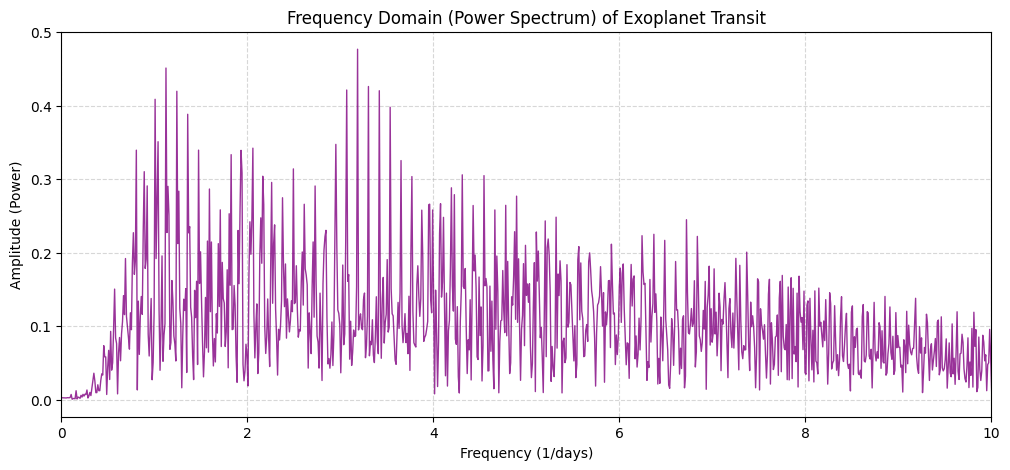

In [ ]:
# Calculate the time step (dt) between measurements.
# Assume that measurements were taken at regular intervals.
dt = time_vals[1] - time_vals[0]

# Get the frequencies and their amplitudes
freqs, power = compute_fft(detrended_flux, dt)

# Visualization Power Spectrum
plt.figure(figsize=(12, 5))
plt.plot(freqs, power, color='purple', alpha=0.8, linewidth=1)

plt.title("Frequency Domain (Power Spectrum) of Exoplanet Transit")
plt.xlabel("Frequency (1/days)")
plt.ylabel("Amplitude (Power)")
plt.grid(True, linestyle='--', alpha=0.5)

# Exoplanets usually have low frequencies (orbital periods of several days).
# Let's limit the X-axis to consider the useful signal, cutting out high-frequency noise.
plt.xlim(0, 10) 

#### Feature Fusion
Concatenate the **FFT** features with `clean_features.csv` → save as `fft_features.csv` to `data/processed/`.

In [7]:
# Adding the root directory of the project to sys.path
sys.path.append(os.path.abspath('..'))

from src.features import generate_fft_dataset

# 1. Data Loading 
print("Loading clean datasets...")
clean_flux = pd.read_csv('../data/processed/clean_flux.csv')
clean_time = pd.read_csv('../data/processed/clean_time.csv')

# 2. Feature Extraction 
# n_features=500 will save only low frequencies, cutting off high frequency noise
fft_features_df = generate_fft_dataset(clean_flux, clean_time, n_features=500)


print("\nNew Dataset Head:")
display(fft_features_df.head())

# 3. Data Saving
output_path = '../data/processed/fft_features.csv'
fft_features_df.to_csv(output_path, index=False)
print(f"\nFFT features successfully saved to {output_path}")

Loading clean datasets...
Starting Feature Extraction (FFT)...
Processed 1000/5899 stars...
Processed 2000/5899 stars...
Processed 3000/5899 stars...
Processed 4000/5899 stars...
Processed 5000/5899 stars...
Feature Extraction Complete. New shape: (5899, 502)

New Dataset Head:


,id,class,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,freq_8,...,freq_491,freq_492,freq_493,freq_494,freq_495,freq_496,freq_497,freq_498,freq_499,freq_500
0,1162345.0,0.0,0.000763,0.000774,0.000791,0.000813,0.000843,0.000874,0.000931,0.000954,...,0.016656,0.007438,0.003610,0.010416,0.010721,0.016944,0.008080,0.007831,0.009677,0.006871
1,1292087.0,0.0,0.000168,0.000165,0.000160,0.000154,0.000146,0.000142,0.000133,0.000129,...,0.004219,0.002121,0.014242,0.027334,0.010526,0.009822,0.025769,0.006777,0.011736,0.009584
2,1293031.0,0.0,0.000622,0.000617,0.000610,0.000599,0.000586,0.000569,0.000559,0.000540,...,0.005320,0.004153,0.008105,0.011262,0.013913,0.018974,0.012958,0.003314,0.010264,0.009623
3,1162345.0,0.0,0.000763,0.000774,0.000791,0.000813,0.000843,0.000874,0.000931,0.000954,...,0.016656,0.007438,0.003610,0.010416,0.010721,0.016944,0.008080,0.007831,0.009677,0.006871
4,1164109.0,0.0,0.000534,0.000530,0.000520,0.000527,0.000485,0.000470,0.000490,0.000454,...,0.003419,0.006595,0.006054,0.003776,0.003271,0.003024,0.003531,0.002132,0.003421,0.003830



FFT features successfully saved to ../data/processed/fft_features.csv
